# Regresión Logística

En este ejercicio aplicamos regresión logística para clasificar correos electrónicos como SPAM o HAM (no spam), usando el dataset TREC 2007 preprocesado de Kaggle.
A diferencia de la regresión lineal que predice valores continuos, la regresión logística predice probabilidades mediante la función sigmoide:

$$\sigma(z) = \frac{1}{1 + e^{-z}} \quad \text{donde} \quad z = \theta_0 + \theta_1 x_1 + ... + \theta_n x_n$$

La salida siempre estará entre 0 y 1, interpretándose como la probabilidad de que el correo sea SPAM.

Para acceder al dataset online entrar [aquí](https://www.kaggle.com/datasets/imdeepmind/preprocessed-trec-2007-public-corpus-dataset).

# 0. Imports

In [2]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

%matplotlib inline

# 1. Carga del Dataset

In [3]:
df = pd.read_csv("data/processed_data.csv")
df

,label,subject,email_to,email_from,message
0,1,"Generic Cialis, branded quality@",the00@speedy.uwaterloo.ca,"""Tomas Jacobs"" <RickyAmes@aol.com>",Content-Type: text/html;\nContent-Transfer-Enc...
1,0,Typo in /debian/README,debian-mirrors@lists.debian.org,Yan Morin <yan.morin@savoirfairelinux.com>,"Hi, i've just updated from the gulus and I che..."
2,1,authentic viagra,<the00@plg.uwaterloo.ca>,"""Sheila Crenshaw"" <7stocknews@tractionmarketin...","Content-Type: text/plain;\n\tcharset=""iso-8859..."
3,1,Nice talking with ya,opt4@speedy.uwaterloo.ca,"""Stormy Dempsey"" <vqucsmdfgvsg@ruraltek.com>","Hey Billy, \n\nit was really fun going out the..."
4,1,or trembling; stomach cramps; trouble in sleep...,ktwarwic@speedy.uwaterloo.ca,"""Christi T. Jernigan"" <dcube@totalink.net>",Content-Type: multipart/alternative;\n ...
...,...,...,...,...,...
75414,1,the reply for your request for a job place [le...,"""Gnitpick"" <gnitpick@flax9.uwaterloo.ca>","""Sydney Car Centre"" <Merrill8783@168city.com>",Content-Type: text/html;\nContent-Transfer-Enc...
75415,1,the reply for your request for a job place [le...,"""Gnitpick"" <gnitpick@flax9.uwaterloo.ca>","""Sydney Car Centre"" <Merrill8783@168city.com>",Content-Type: text/html;\nContent-Transfer-Enc...
75416,0,"Re: [R] Me again, about the horrible documenta...",Duncan Murdoch <murdoch@stats.uwo.ca>,Philippe Grosjean <phgrosjean@sciviews.org>,"For those who are interested, I just cook a li..."
75417,0,Re: [R] RODBC problem,<r-help@stat.math.ethz.ch>,=?iso-8859-1?Q?Bernhard_Wellh=F6fer?=\n\t<Bern...,"Hello,\n\nas I wrote I call\n\n sqlFetch(chan..."


In [39]:
df['label'].value_counts()

label
1    50199
0    25220
Name: count, dtype: int64

0 = HAM,
1 = SPAM

# 2. Limpieza de Datos

In [46]:
# Conteo de duplicados
df.duplicated(subset=['subject', 'email_from', 'email_to', 'message']).sum()

1513

In [47]:
# Conteo de nulos
df[['subject', 'message', 'label']].isnull().sum()

subject     793
message    1487
label         0
dtype: int64

In [48]:
# Eliminar duplicados
df = df.drop_duplicates(subset=['subject', 'email_from', 'email_to', 'message']).reset_index(drop=True)

In [49]:
df.shape

(73906, 5)

# 3. Preprocesamiento del Texto

El algoritmo no puede trabajar con texto directamente, sino con números. Se utiliza 'CountVectorizer' para convertir cada correo en un vector que cuente cuántas veces aparece cada palabra del vocabulario.

In [25]:
# Se combina asunto y cuerpo en una sola cadena de texto por correo
df['text'] = df['subject'].fillna('') + ' ' + df['message'].fillna('')

In [26]:
# Se mantiene el orden temporal del dataset para simular un escenario real:
# entrenamos con correos antiguos y predecimos sobre correos más recientes
split = int(len(df) * 0.8)

X_train_raw = df['text'][:split] # desde la posición 0 hasta split-1
X_test_raw  = df['text'][split:] # desde split hasta el final
y_train = df['label'][:split]
y_test  = df['label'][split:]

In [27]:
# fit_transform sobre train: aprende el vocabulario y transforma a la vez
# transform sobre test: solo transforma usando el vocabulario ya aprendido
# Nunca se hace fit con datos de test — causaría fuga de datos
# max_features limita el vocabulario a las 10.000 palabras más frecuentes
# para ignorar palabras rarísimas que aparecen 1 o 2 veces y aportan poco
vectorizer = CountVectorizer(max_features=10000)
X_train = vectorizer.fit_transform(X_train_raw)
X_test  = vectorizer.transform(X_test_raw)

print(f"Dimensiones de X_train: {X_train.shape}")
print("→ {0} correos × {1} palabras del vocabulario".format(*X_train.shape))

Dimensiones de X_train: (59124, 10000)
→ 59124 correos × 10000 palabras del vocabulario


# 4. Entrenamiento del Modelo

In [28]:
# max_iter=1000 porque con vocabularios grandes el optimizador necesita
# más iteraciones para que los 0 converjan
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

print(f"Número de parámetros θ aprendidos: {clf.coef_.shape[1]}")
print("→ Un θ por cada palabra del vocabulario")

Número de parámetros θ aprendidos: 10000
→ Un θ por cada palabra del vocabulario


Cada palabra tiene un θ asociado. Un θ positivo alto indica que esa palabra es fuertemente indicativa de SPAM. Un θ negativo indica que aparece más en correos legítimos. La función sigmoide combina todos estos pesos para producir una probabilidad final entre 0 y 1.

In [29]:
# Inspeccionar qué palabras el modelo asocia más fuertemente a cada clase
feature_names = vectorizer.get_feature_names_out()
coefs = clf.coef_[0]

top_spam = sorted(zip(coefs, feature_names), reverse=True)[:15]
top_ham  = sorted(zip(coefs, feature_names))[:15]

print("Palabras más asociadas a SPAM:")
for coef, word in top_spam:
    print(f"  {word:<20} θ = {coef:.3f}")

print("\nPalabras más asociadas a HAM:")
for coef, word in top_ham:
    print(f"  {word:<20} θ = {coef:.3f}")

Palabras más asociadas a SPAM:
  medhelp              θ = 2.783
  gif                  θ = 1.285
  hk                   θ = 1.110
  penis                θ = 1.100
  adf                  θ = 0.985
  girl                 θ = 0.965
  type                 θ = 0.897
  producttestpanel     θ = 0.893
  sort                 θ = 0.885
  viewing              θ = 0.868
  dem                  θ = 0.843
  id                   θ = 0.834
  look                 θ = 0.831
  alt                  θ = 0.824
  rent                 θ = 0.791

Palabras más asociadas a HAM:
  lh                   θ = -2.983
  perl                 θ = -2.470
  wrote                θ = -2.357
  reform               θ = -2.041
  samba                θ = -1.549
  following            θ = -1.548
  debian               θ = -1.538
  hello                θ = -1.495
  function             θ = -1.454
  lists                θ = -1.428
  code                 θ = -1.292
  matrix               θ = -1.292
  test                 θ = -1.274
 

# 5. Predicción y Evaluación

In [30]:
# para cada correo aplica σ(θᵀx) y devuelve 1 si P(SPAM)>0.5, 0 si no
y_pred = clf.predict(X_test)

# predict_proba devuelve [P(HAM), P(SPAM)] para cada correo
probs = clf.predict_proba(X_test)

print(f"{'Predicción':<12} {'P(HAM)':<10} {'P(SPAM)':<10} {'Real'}") 
print("-" * 45)
for i in range(5):
    pred = "SPAM" if y_pred[i] == 1 else "HAM"
    real = "SPAM" if list(y_test)[i] == 1 else "HAM"
    print(f"{pred:<12} {probs[i][0]:<10.3f} {probs[i][1]:<10.3f} {real}")

Predicción   P(HAM)     P(SPAM)    Real
---------------------------------------------
SPAM         0.000      1.000      SPAM
SPAM         0.000      1.000      SPAM
SPAM         0.000      1.000      SPAM
HAM          1.000      0.000      HAM
SPAM         0.000      1.000      SPAM


In [31]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")

Accuracy: 0.990


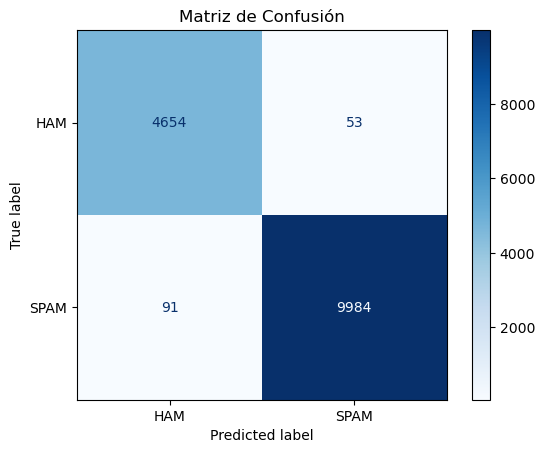

In [32]:
# La matriz de confusión muestra los 4 tipos de resultado posibles:
# Verdaderos Negativos (HAM bien clasificado)  | Falsos Positivos (HAM clasificado como SPAM)
# Falsos Negativos (SPAM no detectado)         | Verdaderos Positivos (SPAM bien detectado)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['HAM', 'SPAM'])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión")
plt.show()


Es más probable que un correo SPAM se cuele en la bandeja a que un correo legítimo sea bloqueado, algo muy importante pues sería un problema grave para el usuario.

# 6. Impacto del tamaño del Dataset

Comprobar que el accuracy mejora a medida que aumentan los datos

In [33]:
sizes = [500, 1000, 5000, 10000, 30000, 40000, 50000, split]
results = []

for n in sizes:
    vec = CountVectorizer(max_features=10000)
    X_tr = vec.fit_transform(df['text'][:n])
    X_te = vec.transform(X_test_raw)
    
    model = LogisticRegression(max_iter=1000)
    model.fit(X_tr, df['label'][:n])
    acc = accuracy_score(y_test, model.predict(X_te))
    results.append(acc)
    print(f"n={n:<7} → Accuracy: {acc:.3f}")

n=500     → Accuracy: 0.906
n=1000    → Accuracy: 0.929
n=5000    → Accuracy: 0.963
n=10000   → Accuracy: 0.967
n=30000   → Accuracy: 0.982
n=40000   → Accuracy: 0.981
n=50000   → Accuracy: 0.979
n=59124   → Accuracy: 0.990


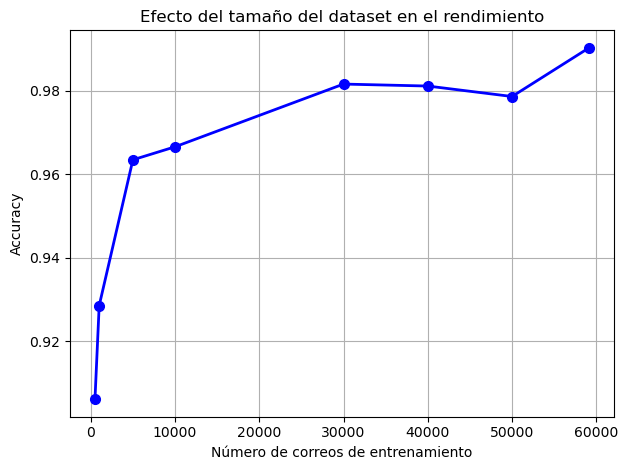

In [34]:
plt.plot(sizes, results, 'bo-', linewidth=2, markersize=7)
plt.xlabel("Número de correos de entrenamiento")
plt.ylabel("Accuracy")
plt.title("Efecto del tamaño del dataset en el rendimiento")
plt.grid(True)
plt.tight_layout()
plt.show()

El accuracy crece consistentemente con más datos, con el mayor salto ocurriendo en los primeros 5000 correos. Entre 30000 y 50000 hay una meseta leve antes de continuar subiendo, lo que sugiere que el modelo aún no ha alcanzado su techo con este dataset. Es decir, con más datos podría mejorar aún más.